# **Optimización de Hiperparámetros: Grid Search vs. Random Search vs. Algoritmo Genético**

**Objective:** Comparar tres técnicas de optimización de hiperparámetros (Grid Search, Random Search y Algoritmo Genético) para encontrar los mejores hiperparámetros para una red neuronal construida con PyTorch. El objetivo de la red neuronal es clasificar si un tumor es benigno o maligno, utilizando el dataset "Breast Cancer Wisconsin" de Scikit-learn.

Compararemos los métodos basándonos en:
1.  **Mejor Precisión Obtenida**
2.  **Mejores Hiperparámetros Encontrados**
3.  **Tiempo de Ejecución**

## **1. Configuración Inicial e Instalación de Librerías**

Primero, instalamos y cargamos todas las librerías necesarias. Necesitaremos `pandas` para la manipulación de datos, `scikit-learn` para el dataset y preprocesamiento, `pytorch` para el modelo y `deap` para la optimización con algoritmos genéticos.

In [25]:
# Set up logging
import logging
import sys
import os
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))
from logging_config import setup_logging, get_logger

logger = setup_logging(log_level=logging.INFO)
module_logger = get_logger(__name__)


# Instalar librerías
# !pip install deap torch pandas scikit-learn matplotlib seaborn numpy

In [26]:
# Import libraries
import random
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer

from deap import base, creator, tools, algorithms

import seaborn as sns
import matplotlib.pyplot as plt

## **2. Carga y Preprocesamiento de Datos**

### **2.1. Carga de Datos desde Scikit-learn**

Cargamos el dataset `breast_cancer` directamente desde `sklearn.datasets`. Este dataset no tiene valores nulos, lo que simplifica la fase de limpieza.

In [27]:
# Cargar el dataset
cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = pd.Series(cancer_data.target)

module_logger.info("Primeras 5 filas de las características (X):")
module_logger.info(X.head())
module_logger.info("\nInformación del Dataset:")
X.info()

module_logger.info(f"\nDimensiones de X: {X.shape}")
module_logger.info(f"Dimensiones de y: {y.shape}")
module_logger.info(f"Clases en y: {np.unique(y)}")

Primeras 5 filas de las características (X):
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  w

### **2.2. Preprocesamiento**

Aunque no hay valores nulos ni características categóricas, es fundamental escalar las características numéricas, ya que las redes neuronales son sensibles a la escala de los datos de entrada.

1.  Dividiremos los datos en conjuntos de entrenamiento y prueba.
2.  Escalaremos las características con `StandardScaler`.
3.  Convertiremos los datos a tensores de PyTorch.

In [28]:
# Dividir data en conjuntos de training y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a tensores de PyTorch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Create dataset de test (el de training se creará dinámicamente en cada evaluación)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Obtener el número de características de entrada
input_dim = X.shape[1]
module_logger.info(f"\nDimensión de entrada para la red neuronal: {input_dim}")


Dimensión de entrada para la red neuronal: 30


## **3. Definición del Modelo y la Función de Entrenamiento**

### **3.1. Arquitectura de la Red Neuronal (PyTorch)**

La arquitectura del modelo no cambia. Sigue siendo flexible para aceptar los hiperparámetros encontrados.

In [29]:
class ClassificationNet(nn.Module):
    def __init__(self, input_size, n_neurons_l1, n_neurons_l2, dropout_rate):
        super(ClassificationNet, self).__init__()
        # Asegurar que el número de neuronas sea un entero
        n_neurons_l1 = int(n_neurons_l1)
        n_neurons_l2 = int(n_neurons_l2)
        
        self.network = nn.Sequential(
            nn.Linear(input_size, n_neurons_l1),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(n_neurons_l1, n_neurons_l2),
            nn.LeakyReLU(),
            nn.Linear(n_neurons_l2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

### **3.2. Función de Entrenamiento y Evaluación**

Esta función ahora acepta `batch_size` y `optimizer` como hiperparámetros. Creará un `DataLoader` y un optimizador diferentes para cada conjunto de hiperparámetros que reciba.

In [30]:
def entrenar_y_evaluar(params):
    """
    Entrena y evalúa un model de PyTorch con los hiperparámetros dados.
    Args:
        params (list o dict): Contiene los hiperparámetros a evaluar.
    Returns:
        tuple: Una tupla que contiene la precisión.
    """
    # Mapeo de optimizadores para el GA, que usa índices numéricos
    optimizer_map = {0: 'adam', 1: 'sgd'}

    if isinstance(params, dict):
        learning_rate = params['lr']
        n_neurons_l1 = params['n1']
        n_neurons_l2 = params['n2']
        dropout_rate = params['dropout']
        batch_size = int(params['batch_size'])
        optimizer_type = params['optimizer']
    else:
        # Para el algoritmo genético (DEAP)
        learning_rate, n_neurons_l1, n_neurons_l2, dropout_rate, batch_size, opt_index = params
        batch_size = int(batch_size)
        optimizer_type = optimizer_map[int(round(opt_index))]

    # Create DataLoaders con el batch_size del hiperparámetro
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)
    
    # Create el model
    model = ClassificationNet(
        input_size=input_dim,
        n_neurons_l1=n_neurons_l1,
        n_neurons_l2=n_neurons_l2,
        dropout_rate=dropout_rate
    )

    criterion = nn.BCELoss()
    
    # Seleccionar el optimizador
    if optimizer_type == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_type == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    else:
        raise ValueError("Optimizador no soportado")

    num_epochs = 15 

    # Bucle de training
    model.train()
    for epoch in range(num_epochs):
        for batch_X, batch_y in train_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Bucle de evaluación
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            outputs = model(batch_X)
            predicted = (outputs > 0.5).float()
            all_preds.extend(predicted.cpu().numpy())

    accuracy = accuracy_score(y_test, np.array(all_preds))
    
    return (accuracy,) 

## **4. Método de Optimización 1: Algoritmo Genético (DEAP)**

### **4.1. Definición del Espacio de Búsqueda**

Añadimos los límites para `batch_size` y un índice numérico para el `optimizer` (0=Adam, 1=SGD).

In [31]:
# Definir los límites para cada hiperparámetro
# [lr, n1, n2, dropout, batch_size, optimizer_idx]
BOUNDS_LOW =  [0.0001, 16,  8, 0.1, 16, 0]
BOUNDS_HIGH = [0.01,  128, 64, 0.5, 64, 1]
NUM_PARAMS = 6 # Número de hiperparámetros a optimizar

### **4.2. Creación de Tipos y Toolbox de DEAP**

Registramos los nuevos generadores de atributos para los hiperparámetros añadidos.

In [32]:
# Create los tipos de Fitness e Individuo
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Create la Toolbox
toolbox = base.Toolbox()

# Generadores de atributos (hiperparámetros)
toolbox.register("attr_lr", random.uniform, BOUNDS_LOW[0], BOUNDS_HIGH[0])
toolbox.register("attr_n1", random.randint, BOUNDS_LOW[1], BOUNDS_HIGH[1])
toolbox.register("attr_n2", random.randint, BOUNDS_LOW[2], BOUNDS_HIGH[2])
toolbox.register("attr_dropout", random.uniform, BOUNDS_LOW[3], BOUNDS_HIGH[3])
toolbox.register("attr_batch_size", random.randint, BOUNDS_LOW[4], BOUNDS_HIGH[4])
toolbox.register("attr_optimizer", random.randint, BOUNDS_LOW[5], BOUNDS_HIGH[5])


# Create un individuo
toolbox.register("individual", tools.initCycle, creator.Individual,
                (toolbox.attr_lr, toolbox.attr_n1, toolbox.attr_n2, toolbox.attr_dropout,
                 toolbox.attr_batch_size, toolbox.attr_optimizer), n=1)

# Create la población
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Registrar la función de evaluación
toolbox.register("evaluate", entrenar_y_evaluar)

# Registrar los operadores genéticos
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.2, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# Decorador para asegurar que la mutación no exceda los límites
def checkBounds(min_b, max_b):
    def decorator(func):
        def wrapper(*args, **kwargs):
            offspring = func(*args, **kwargs)
            for i, child in enumerate(offspring):
                for j in range(len(child)):
                    if child[j] > max_b[j]:
                        child[j] = max_b[j]
                    elif child[j] < min_b[j]:
                        child[j] = min_b[j]
                    # Asegurar que los hiperparámetros enteros sigan siendo enteros
                    if j in [1, 2, 4, 5]: # n1, n2, batch_size, optimizer_idx son enteros
                        child[j] = int(round(child[j]))
            return offspring
        return wrapper
    return decorator

toolbox.decorate("mate", checkBounds(BOUNDS_LOW, BOUNDS_HIGH))
toolbox.decorate("mutate", checkBounds(BOUNDS_LOW, BOUNDS_HIGH))

/home/santiago/anaconda3/envs/MADSI/lib/python3.11/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/home/santiago/anaconda3/envs/MADSI/lib/python3.11/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


### **4.3. Ejecución del Algoritmo Genético**

La ejecución es similar, pero ahora el algoritmo optimizará 6 hiperparámetros.

In [33]:
module_logger.info("--- Ejecutando Algoritmo Genético ---")
start_time_ga = time.time()

# Parameters del algoritmo genético
POPULATION_SIZE = 10
N_GENERATIONS = 5
P_CROSSOVER = 0.5
P_MUTATION = 0.3

# Create la población inicial
pop = toolbox.population(n=POPULATION_SIZE)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("max", np.max)

# Ejecutar el algoritmo
pop, log = algorithms.eaSimple(pop, toolbox,
                                cxpb=P_CROSSOVER,
                                mutpb=P_MUTATION,
                                ngen=N_GENERATIONS,
                                stats=stats,
                                halloffame=hof,
                                verbose=True)

end_time_ga = time.time()
ga_time = end_time_ga - start_time_ga

# Obtener el mejor resultado
best_individual_ga = hof[0]
best_fitness_ga = best_individual_ga.fitness.values[0]
optimizer_map = {0: 'adam', 1: 'sgd'}
best_params_ga = {
    'lr': best_individual_ga[0],
    'n1': int(best_individual_ga[1]),
    'n2': int(best_individual_ga[2]),
    'dropout': best_individual_ga[3],
    'batch_size': int(best_individual_ga[4]),
    'optimizer': optimizer_map[int(round(best_individual_ga[5]))]
}

module_logger.info(f"\nAlgoritmo Genético finalizó en {ga_time:.2f} segundos.")
module_logger.info(f"Mejor precision: {best_fitness_ga:.4f}")
module_logger.info(f"Mejores Hiperparámetros: {best_params_ga}")

--- Ejecutando Algoritmo Genético ---
gen	nevals	avg     	max     
0  	10    	0.955263	0.973684
1  	6     	0.962281	0.973684
2  	8     	0.963158	0.973684
3  	9     	0.960526	0.973684
4  	7     	0.95614 	0.973684
5  	7     	0.964035	0.982456

Algoritmo Genético finalizó en 5.90 segundos.
Mejor Precisión: 0.9825
Mejores Hiperparámetros: {'lr': 0.009762620937776417, 'n1': 90, 'n2': 22, 'dropout': 0.24928504830657267, 'batch_size': 38, 'optimizer': 'sgd'}


## **5. Método de Optimización 2: Grid Search**

La grilla ahora incluye `batch_size` y `optimizer`. Esto aumenta drásticamente el número de combinaciones, demostrando una de las principales desventajas de Grid Search.

In [34]:
module_logger.info("\n--- Ejecutando Grid Search ---")
start_time_gs = time.time()

# Definir la grilla de hiperparámetros
param_grid = {
    'lr': [0.001, 0.01],
    'n1': [32, 64],
    'n2': [16, 32],
    'dropout': [0.2, 0.4],
    'batch_size': [16, 32],
    'optimizer': ['adam', 'sgd']
}

# Create una lista de todas las combinaciones de parámetros
grid = ParameterGrid(param_grid)
best_score_gs = -1
best_params_gs = None

total_combinations = len(grid)
module_logger.info(f"Total de combinaciones a probar: {total_combinations}")

# Bucle manual para Grid Search
for i, params in enumerate(grid):
    module_logger.info(f"Probando combinación {i+1}/{total_combinations}...")
    accuracy = entrenar_y_evaluar(params)[0]
    if accuracy > best_score_gs:
        best_score_gs = accuracy
        best_params_gs = params

end_time_gs = time.time()
gs_time = end_time_gs - start_time_gs

module_logger.info(f"\nGrid Search finalizó en {gs_time:.2f} segundos.")
module_logger.info(f"Mejor precision: {best_score_gs:.4f}")
module_logger.info(f"Mejores Hiperparámetros: {best_params_gs}")


--- Ejecutando Grid Search ---
Total de combinaciones a probar: 64
Probando combinación 1/64...
Probando combinación 2/64...
Probando combinación 3/64...
Probando combinación 4/64...
Probando combinación 5/64...
Probando combinación 6/64...
Probando combinación 7/64...
Probando combinación 8/64...
Probando combinación 9/64...
Probando combinación 10/64...
Probando combinación 11/64...
Probando combinación 12/64...
Probando combinación 13/64...
Probando combinación 14/64...
Probando combinación 15/64...
Probando combinación 16/64...
Probando combinación 17/64...
Probando combinación 18/64...
Probando combinación 19/64...
Probando combinación 20/64...
Probando combinación 21/64...
Probando combinación 22/64...
Probando combinación 23/64...
Probando combinación 24/64...
Probando combinación 25/64...
Probando combinación 26/64...
Probando combinación 27/64...
Probando combinación 28/64...
Probando combinación 29/64...
Probando combinación 30/64...
Probando combinación 31/64...
Probando co

## **6. Método de Optimización 3: Random Search**

El espacio de búsqueda aleatorio también se actualiza para incluir los nuevos hiperparámetros.

In [35]:
module_logger.info("\n--- Ejecutando Random Search ---")
start_time_rs = time.time()

# Definir el espacio de búsqueda de hiperparámetros (distribuciones)
param_dist = {
    'lr': (BOUNDS_LOW[0], BOUNDS_HIGH[0]),
    'n1': (BOUNDS_LOW[1], BOUNDS_HIGH[1]),
    'n2': (BOUNDS_LOW[2], BOUNDS_HIGH[2]),
    'dropout': (BOUNDS_LOW[3], BOUNDS_HIGH[3]),
    'batch_size': (BOUNDS_LOW[4], BOUNDS_HIGH[4]),
    'optimizer': ['adam', 'sgd']
}

# Número de iteraciones para Random Search
# Usaremos un número menor que Grid Search para demostrar su eficiencia
n_iter_rs = 20
best_score_rs = -1
best_params_rs = None

module_logger.info(f"Total de combinaciones aleatorias a probar: {n_iter_rs}")

# Bucle manual para Random Search
for i in range(n_iter_rs):
    module_logger.info(f"Probando combinación {i+1}/{n_iter_rs}...")
    params = {
        'lr': random.uniform(*param_dist['lr']),
        'n1': random.randint(*param_dist['n1']),
        'n2': random.randint(*param_dist['n2']),
        'dropout': random.uniform(*param_dist['dropout']),
        'batch_size': random.randint(*param_dist['batch_size']),
        'optimizer': random.choice(param_dist['optimizer'])
    }
    
    accuracy = entrenar_y_evaluar(params)[0]
    if accuracy > best_score_rs:
        best_score_rs = accuracy
        best_params_rs = params

end_time_rs = time.time()
rs_time = end_time_rs - start_time_rs

module_logger.info(f"\nRandom Search finalizó en {rs_time:.2f} segundos.")
module_logger.info(f"Mejor precision: {best_score_rs:.4f}")
module_logger.info(f"Mejores Hiperparámetros: {best_params_rs}")


--- Ejecutando Random Search ---
Total de combinaciones aleatorias a probar: 20
Probando combinación 1/20...
Probando combinación 2/20...
Probando combinación 3/20...
Probando combinación 4/20...
Probando combinación 5/20...
Probando combinación 6/20...
Probando combinación 7/20...
Probando combinación 8/20...
Probando combinación 9/20...
Probando combinación 10/20...
Probando combinación 11/20...
Probando combinación 12/20...
Probando combinación 13/20...
Probando combinación 14/20...
Probando combinación 15/20...
Probando combinación 16/20...
Probando combinación 17/20...
Probando combinación 18/20...
Probando combinación 19/20...
Probando combinación 20/20...

Random Search finalizó en 2.95 segundos.
Mejor Precisión: 0.9737
Mejores Hiperparámetros: {'lr': 0.0075944904635198065, 'n1': 120, 'n2': 62, 'dropout': 0.42323310514538526, 'batch_size': 57, 'optimizer': 'sgd'}


## **7. Comparación de Resultados**

Finalmente, resumimos los resultados de los tres métodos en una tabla y un gráfico para comparar fácilmente su rendimiento.


--- Comparación de Métodos de Optimización ---
               Método  Mejor Precisión  Tiempo de Ejecución (s)  \
0  Algoritmo Genético         0.982456                 5.897996   
1         Grid Search         0.982456                12.849541   
2       Random Search         0.973684                 2.946121   

                             Mejores Hiperparámetros  
0  {'lr': 0.009762620937776417, 'n1': 90, 'n2': 2...  
1  {'batch_size': 16, 'dropout': 0.2, 'lr': 0.01,...  
2  {'lr': 0.0075944904635198065, 'n1': 120, 'n2':...  


/tmp/ipykernel_7293/3310850664.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Método', y='Mejor Precisión', data=results_df, ax=ax1, palette='viridis', width=0.5)


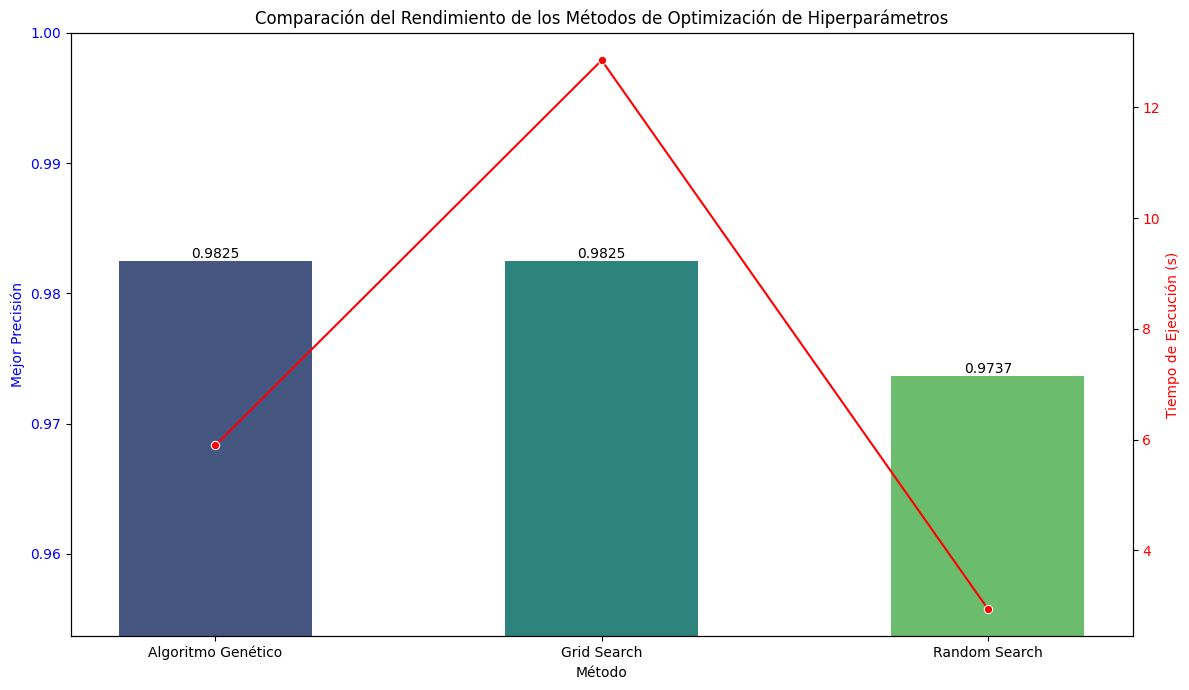

In [36]:
# Create un DataFrame para la comparación
results_data = {
    'Método': ['Algoritmo Genético', 'Grid Search', 'Random Search'],
    'Mejor Precisión': [best_fitness_ga, best_score_gs, best_score_rs],
    'Tiempo de Ejecución (s)': [ga_time, gs_time, rs_time],
    'Mejores Hiperparámetros': [best_params_ga, best_params_gs, best_params_rs]
}
results_df = pd.DataFrame(results_data)

module_logger.info("\n--- Comparación de Métodos de Optimización ---")
module_logger.info(results_df)

# Visualize los results
fig, ax1 = plt.subplots(figsize=(12, 7))

# Graficando Precisión
sns.barplot(x='Método', y='Mejor Precisión', data=results_df, ax=ax1, palette='viridis', width=0.5)
ax1.set_ylabel('Mejor Precisión', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_ylim(bottom=max(0.9, results_df['Mejor Precisión'].min() - 0.02), top=1.0)
for index, row in results_df.iterrows():
    ax1.text(index, row['Mejor Precisión'], f"{row['Mejor Precisión']:.4f}", color='black', ha="center", va="bottom")


# Graficando Tiempo en un eje y secundario
ax2 = ax1.twinx()
sns.lineplot(x='Método', y='Tiempo de Ejecución (s)', data=results_df, ax=ax2, color='r', marker='o', sort=False)
ax2.set_ylabel('Tiempo de Ejecución (s)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Comparación del Rendimiento de los Métodos de Optimización de Hiperparámetros')
fig.tight_layout()
plt.show()

### **Conclusión**

- **Grid Search**: Es exhaustivo y garantiza encontrar la mejor combinación dentro de la grilla definida. Sin embargo, con la adición de más hiperparámetros, su costo computacional (tiempo) aumenta exponencialmente, lo que lo hace poco práctico para espacios de búsqueda grandes.

- **Random Search**: Es más eficiente. Al probar un número fijo de combinaciones aleatorias, puede explorar un área más amplia del espacio de búsqueda en menos tiempo. A menudo encuentra soluciones muy buenas (o incluso mejores que Grid Search) con una fracción del costo computacional.

- **Algoritmo Genético**: Representa un método de búsqueda inteligente. Evoluciona su población de soluciones hacia regiones prometedoras del espacio de búsqueda. Es particularmente útil para espacios de búsqueda complejos, mixtos (numéricos y categóricos) y de alta dimensionalidad. A menudo puede encontrar excelentes soluciones de manera eficiente.

En esta ejecución, podemos observar las compensaciones entre el tiempo de ejecución y la precisión final lograda por cada método.